In [1]:
from funcoes_fundamentais import *
import pandas as pd
import numpy as np


In [ ]:
# Instalação das dependências necessárias no ambiente
# Nota: spacecore==0.4.2 é recomendado para total compatibilidade com sdplab==0.0.1
! pip install -q numpy matplotlib scipy "spacecore==0.4.2" sdplab cvxpy clarabel scs jax

In [3]:
from __future__ import annotations

import sys
from typing import Any, Dict, List, Optional, Sequence, Tuple, Union
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
# Bibliotecas SpaceCore e SDPLab para Programação Semidefinida 
import spacecore
from spacecore import Context, DenseVectorSpace, HermitianSpace, NumpyOps
import sdplab
from sdplab import DenseConstraintOp, SDPProblem
from sdplab.solvers import run_cvxpy_solver

np.set_printoptions(precision=4, suppress=True)

from funcoes_fundamentais import zero, one, ketbra, verifica_densidade, verify_marginals, base_hermitiana, ghz, partial_trace, tensor, embed_operator, solve_qmp, build_qmp_sdp, parse_subsystem_key, basis
print(f"Versão SDPLab:    {sdplab.__version__}")
print(f"Versão SpaceCore: {spacecore.__version__}")

Versão SDPLab:    0.0.1
Versão SpaceCore: 0.4.2


## 9. Exemplo 1: Marginais do Estado GHZ

### Descrição Física
Para o estado puro tripartite $|GHZ\rangle = \frac{|000\rangle + |111\rangle}{\sqrt{2}}$, o traço parcial sobre qualquer um dos qubits produz a mesma mistura clássica invariante de 2 qubits:

$$\omega_{AB} = \omega_{AC} = \omega_{BC} = \frac{1}{2}(|00\rangle\langle 00| + |11\rangle\langle 11|) = \begin{pmatrix} 0.5 & 0 & 0 & 0 \\ 0 & 0 & 0 & 0 \\ 0 & 0 & 0 & 0 \\ 0 & 0 & 0 & 0.5 \end{pmatrix}$$

### Regime Esperado
- **Mixed Representability:** **SIM** (factível). O SDP encontra uma matriz global válida $\rho_{ABC}$ (comumente a mistura clássica $\frac{1}{2}(|000\rangle\langle 000| + |111\rangle\langle 111|)$).
- **Pure Representability:** **SIM**, pois o estado puro $|GHZ\rangle$ existe e tem exatamente estas marginais.
- **Pureza esperada da mistura:** $\gamma = 0.5$, com dois autovalores iguais a $0.5$ e os demais nulos.

In [3]:
# Montagem das marginais do estado GHZ
omega_ghz_2qubits = 0.5 * (ketbra(np.kron(zero, zero)) + ketbra(np.kron(one, one)))

marginals_ex1 = {
    "AB": omega_ghz_2qubits,
    "AC": omega_ghz_2qubits,
    "BC": omega_ghz_2qubits,
}

print("Exemplo 1 (GHZ)")
sdp_ex1, M_ex1, b_ex1 = build_qmp_sdp(marginals_ex1, dims=[2, 2, 2])
print(f"SDP construído: dimensão do domínio = {sdp_ex1.dom.n}x{sdp_ex1.dom.n}, restrições m = {len(b_ex1)}")

# Resolução com CLARABEL
res_ex1 = solve_qmp(sdp_ex1, solver="CLARABEL")
print(f"Status do Solver: {res_ex1['status']} | Factível: {res_ex1['is_feasible']}")

# Auditoria
verif_ex1 = verify_marginals(res_ex1["rho"], marginals_ex1, dims=[2, 2, 2])
print(f"Erro de Hermiticidade:  {verif_ex1['hermitian_error']:.2e}")
print(f"Traço Tr(rho):          {verif_ex1['trace'].real:.12f} (Erro: {verif_ex1['trace_error']:.2e})")
print(f"lambda_min:             {verif_ex1['min_eigenvalue']:.2e} -> rho >= 0: {verif_ex1['is_psd']}")
print(f"Pureza Tr(rho^2):       {verif_ex1['purity']:.4f}")
print("Autovalores de rho_ABC:")
print(" ", np.round(verif_ex1["eigenvalues"], 6))
print("Resíduos por marginal:")
for k, err in verif_ex1["marginal_errors"].items():
    print(f"  Marginal {k}: Erro Frobenius = {err['frobenius_error']:.2e}, Max Abs = {err['max_abs_error']:.2e}")

Exemplo 1 (GHZ)
SDP construído: dimensão do domínio = 8x8, restrições m = 49
Status do Solver: optimal | Factível: True
Erro de Hermiticidade:  0.00e+00
Traço Tr(rho):          1.000000000000 (Erro: 2.44e-15)
lambda_min:             1.23e-15 -> rho >= 0: True
Pureza Tr(rho^2):       0.5000
Autovalores de rho_ABC:
  [0.  0.  0.  0.  0.  0.  0.5 0.5]
Resíduos por marginal:
  Marginal AB: Erro Frobenius = 4.57e-15, Max Abs = 2.82e-15
  Marginal AC: Erro Frobenius = 4.57e-15, Max Abs = 2.82e-15
  Marginal BC: Erro Frobenius = 4.57e-15, Max Abs = 2.82e-15


## 10. Exemplo 2: Marginais Maximamente Mistas

### Descrição Física
Prescrevemos que as três marginais bipartidas sejam maximamente mistas em 2 qubits:

$$\omega_{AB} = \omega_{AC} = \omega_{BC} = \frac{I_4}{4}$$

### Regime Esperado
- **Mixed Representability:** **SIM** (factível). O estado global maximamente misto $\rho_{ABC} = \frac{I_8}{8}$ satisfaz exatamente $\operatorname{Tr}_C(I_8 / 8) = I_4 / 4$.
- **Pure Representability:** **NÃO**.


In [4]:
# Montagem das marginais maximamente mistas
omega_max_mixed = np.eye(4, dtype=complex) / 4.0

marginals_ex2 = {
    "AB": omega_max_mixed,
    "AC": omega_max_mixed,
    "BC": omega_max_mixed,
}

print("Exemplo 2 (Maximamente Misto)")
sdp_ex2, M_ex2, b_ex2 = build_qmp_sdp(marginals_ex2, dims=[2, 2, 2])
print(f"SDP construído: dimensão do domínio = {sdp_ex2.dom.n}x{sdp_ex2.dom.n}, restrições m = {len(b_ex2)}")

# Resolução com CLARABEL
res_ex2 = solve_qmp(sdp_ex2, solver="CLARABEL")
print(f"Status do Solver: {res_ex2['status']} | Factível: {res_ex2['is_feasible']}")

# Auditoria
verif_ex2 = verify_marginals(res_ex2["rho"], marginals_ex2, dims=[2, 2, 2])
print(f"Erro de Hermiticidade:  {verif_ex2['hermitian_error']:.2e}")
print(f"Traço Tr(rho):          {verif_ex2['trace'].real:.12f} (Erro: {verif_ex2['trace_error']:.2e})")
print(f"lambda_min:             {verif_ex2['min_eigenvalue']:.2e} -> rho >= 0: {verif_ex2['is_psd']}")
print(f"Pureza Tr(rho^2):       {verif_ex2['purity']:.4f} (Esperado para I_8/8: 0.1250)")
print("Autovalores de rho_ABC:")
print(" ", np.round(verif_ex2["eigenvalues"], 6))
print("Resíduos por marginal:")
for k, err in verif_ex2["marginal_errors"].items():
    print(f"  Marginal {k}: Erro Frobenius = {err['frobenius_error']:.2e}, Max Abs = {err['max_abs_error']:.2e}")

Exemplo 2 (Maximamente Misto)
SDP construído: dimensão do domínio = 8x8, restrições m = 49
Status do Solver: optimal | Factível: True
Erro de Hermiticidade:  0.00e+00
Traço Tr(rho):          1.000000000000 (Erro: 0.00e+00)
lambda_min:             1.25e-01 -> rho >= 0: True
Pureza Tr(rho^2):       0.1250 (Esperado para I_8/8: 0.1250)
Autovalores de rho_ABC:
  [0.125 0.125 0.125 0.125 0.125 0.125 0.125 0.125]
Resíduos por marginal:
  Marginal AB: Erro Frobenius = 0.00e+00, Max Abs = 0.00e+00
  Marginal AC: Erro Frobenius = 0.00e+00, Max Abs = 0.00e+00
  Marginal BC: Erro Frobenius = 0.00e+00, Max Abs = 0.00e+00


## 11. Exemplo 3: Incompatibilidade de Marginais e Monogamia do Entrelaçamento

### Descrição Física
Tentamos impor que o qubit $A$ esteja **simultaneamente** maximamente entrelaçado em um estado puro de Bell $|\Phi^+\rangle$ com o qubit $B$ e com o qubit $C$:

$$\omega_{AB} = |\Phi^+\rangle\langle\Phi^+|, \quad \omega_{AC} = |\Phi^+\rangle\langle\Phi^+|$$

### Regime Esperado
- **Mixed Representability:** **NÃO** (infactível).
- **Pure Representability:** **NÃO** (infactível).


In [ ]:
# Montagem das marginais incompatíveis de Bell
phi_plus = (np.kron(zero, zero) + np.kron(one, one)) / np.sqrt(2.0)
rho_bell = ketbra(phi_plus)

marginals_ex3 = {
    "AB": rho_bell,
    "AC": rho_bell,
}

#Vamos fazer um tete de consistência

rho_A_de_AB = partial_trace(marginals_ex3["AB"], keep=[0], dims=[2,2])
rho_A_de_AC = partial_trace(marginals_ex3["AC"], keep=[0], dims=[2,2])

overlap_error = np.linalg.norm(
    rho_A_de_AB - rho_A_de_AC,
    ord="fro"
)

print("\nTeste de consistência na sobreposição:")
print("Marginal de A obtida a partir de AB:")
print(rho_A_de_AB)

print("\nMarginal de A obtida a partir de AC:")
print(rho_A_de_AC)

print(f"\nErro de sobreposição ||rho_A^(AB) - rho_A^(AC)||_F = {overlap_error:.3e}")

if np.isclose(overlap_error, 0.0):
    print("A condição de sobreposição é satisfeita.")
    print("Entretanto, isso é apenas uma condição necessária, não suficiente,")
    print("para a existência de uma extensão global.")
else:
    print("A condição de sobreposição é violada.")


print("Exemplo 3 (Incompatibilidade de Bell)")
sdp_ex3, M_ex3, b_ex3 = build_qmp_sdp(marginals_ex3, dims=[2, 2, 2])
print(f"SDP construído: dimensão do domínio = {sdp_ex3.dom.n}x{sdp_ex3.dom.n}, restrições m = {len(b_ex3)}")

# Resolução com CLARABEL
res_ex3 = solve_qmp(sdp_ex3, solver="CLARABEL")
print(f"Status retornado pelo solver: {res_ex3['status']}")
print(f"O problema é factível?        {res_ex3['is_feasible']}")
print(f"Diagnóstico capturado:        {res_ex3['error_message']}")



Teste de consistência na sobreposição:
Marginal de A obtida a partir de AB:
[[0.5+0.j 0. +0.j]
 [0. +0.j 0.5+0.j]]

Marginal de A obtida a partir de AC:
[[0.5+0.j 0. +0.j]
 [0. +0.j 0.5+0.j]]

Erro de sobreposição ||rho_A^(AB) - rho_A^(AC)||_F = 0.000e+00
A condição de sobreposição é satisfeita.
Entretanto, isso é apenas uma condição necessária, não suficiente,
para a existência de uma extensão global.
Exemplo 3 (Incompatibilidade de Bell)
SDP construído: dimensão do domínio = 8x8, restrições m = 33
Status retornado pelo solver: infeasible
O problema é factível?        False
Diagnóstico capturado:        CLARABEL solver did not return a solution (infeasible).


## 12. Exemplo 4: Escalabilidade com Mais Qubits e a Maldição da Dimensão

### 12.1 Fundamentação Teórica da Maldição da Dimensão no QMP

O estudo da compatibilidade de matrizes densidade reduzidas esbarra diretamente no gargalo fundamental da mecânica quântica de muitos corpos: a **maldição da dimensão** (*curse of dimensionality*).

#### 1. Crescimento Exponencial do Espaço de Hilbert
Para um sistema quântico composto por $N$ qubits, o espaço de Hilbert global é o produto tensorial dos espaços locais $\mathcal{H} = (\mathbb{C}^2)^{\otimes N}$, cuja dimensão cresce com potências de 2:

$$\dim(\mathcal{H}) = d = 2^N$$

Como a matriz densidade global $\rho$ atua como um operador linear sobre $\mathcal{H}$, ela pertence ao espaço das matrizes Hermitianas de ordem $d$, denotado por $\mathrm{Herm}(2^N)$. A dimensão real deste espaço vetorial cresce quadraticamente com a dimensão do espaço de Hilbert:

$$\dim_{\mathbb{R}}(\mathrm{Herm}(2^N)) = (2^N)^2 = 4^N$$

O número de parâmetros reais independentes necessários para parametrizar um estado arbitrário $\rho$ (descontando a restrição de traço unitário) é $4^N - 1$:
- **$N = 3$ qubits:** $d = 8$, matriz $8 \times 8 \implies 64$ elementos reais ($63$ graus de liberdade);
- **$N = 4$ qubits:** $d = 16$, matriz $16 \times 16 \implies 256$ elementos reais ($255$ graus de liberdade);
- **$N = 5$ qubits:** $d = 32$, matriz $32 \times 32 \implies 1.024$ elementos reais ($1.023$ graus de liberdade);
- **$N = 6$ qubits:** $d = 64$, matriz $64 \times 64 \implies 4.096$ elementos reais ($4.095$ graus de liberdade);
- **$N = 10$ qubits:** $d = 1.024$, matriz $1.024 \times 1.024 \implies 1.048.576$ elementos reais ($> 10^6$ variáveis);
- **$N = 20$ qubits:** $d \approx 10^6$, matriz com $\approx 1,1 \times 10^{12}$ elementos (impossível até mesmo de ser armazenada na memória RAM dos maiores supercomputadores clássicos).

#### 2. Custo Algorítmico do Solver Semidefinido (SDP)
No problema SDP formulado via SDPLab e resolvido por Métodos de Pontos Interiores (IPM, como o solver `CLARABEL`):
- A variável matricial de decisão é $X \in \mathrm{Herm}(d)$ com a restrição cônica de positividade semidefinida $X \succeq 0$, onde $d = 2^N$.
- O operador linear afim $\mathcal{A}(X) = b$ impõe a normalização $\operatorname{Tr}(X) = 1$ e a projeção sobre as bases Hermitianas das marginais locais fornecidas.
- Em cada iteração de um solver IPM primal-dual, forma-se e fatora-se a matriz hessiana/sistema de Schur de tamanho $m \times m$, além da realização de projeções e produtos matriciais de dimensão $d \times d$. O custo computacional por iteração escala tipicamente como:

$$\mathcal{O}(m \cdot d^3 + m^2 d^2 + m^3) = \mathcal{O}(m \cdot 8^N + m^2 \cdot 4^N + m^3)$$

Mesmo em um regime onde as interações físicas são locais (por exemplo, restringindo apenas marginais bipartidas entre pares de primeiros vizinhos em uma cadeia 1D, onde $m = 1 + 16(N-1)$ cresce de forma perfeitamente **linear** em $N$), o custo computacional por iteração continua crescendo de forma **intrinsecamente exponencial**:

$$\mathcal{O}(N \cdot 8^N + N^2 \cdot 4^N + N^3)$$

#### 3. Dureza Computacional Fundamental (QMA-Completude)
A maldição da dimensão no QMP não é uma limitação da formulação SDP ou do solver numérico adotado. O problema geral de consistência de marginais quânticas locais ($k$-local Quantum Marginal Problem) foi rigorosamente classificado por **Yi-Kai Liu (2006)** como sendo **QMA-completo** (*Quantum Merlin-Arthur*, a classe de complexidade quântica análoga a NP-completo para computadores clássicos).

Isso significa que, a menos que $\mathrm{BQP} = \mathrm{QMA}$ (hipótese considerada amplamente improvável na ciência da computação teórica), **não existe nenhum algoritmo clássico ou quântico** que consiga resolver o QMP geral em tempo polinomial para um número arbitrário de qubits.

In [ ]:
# ==============================================================================
# Exemplo Concreto com N = 4 Qubits: Cadeia 1D com Marginais de Primeiros Vizinhos
# ==============================================================================

import time

N_qubits = 4
dims_4q = [2] * N_qubits

print(f"--- Construindo Instância com N = {N_qubits} Qubits ---")
print(f"Dimensão do Espaço de Hilbert: d = 2^{N_qubits} = {2**N_qubits}")
print(f"Dimensão do Espaço de Operadores: d^2 = 4^{N_qubits} = {4**N_qubits} parâmetros reais")

# 1. Construção do estado global de referência: |GHZ_4> = (|0000> + |1111>) / sqrt(2)
psi_0_4 = tensor(*([zero] * N_qubits))
psi_1_4 = tensor(*([one] * N_qubits))
psi_ghz_4 = (psi_0_4 + psi_1_4) / np.sqrt(2.0)
rho_ghz_4 = ketbra(psi_ghz_4)

print(f"Formato da matriz densidade global rho_4q: {rho_ghz_4.shape} ({rho_ghz_4.size} entradas)")

# 2. Extração das marginais bipartidas de primeiros vizinhos: (0, 1), (1, 2) e (2, 3)
marginals_4q = {
    (0, 1): partial_trace(rho_ghz_4, keep=[0, 1], dims=dims_4q),
    (1, 2): partial_trace(rho_ghz_4, keep=[1, 2], dims=dims_4q),
    (2, 3): partial_trace(rho_ghz_4, keep=[2, 3], dims=dims_4q),
}

print(f"\nMarginais prescritas para subsistemas de primeiros vizinhos ({len(marginals_4q)} pares):")
for pair, mat in marginals_4q.items():
    print(f"  Par {pair}: matriz {mat.shape[0]}x{mat.shape[1]}, Tr(omega) = {np.trace(mat).real:.4f}")

# 3. Construção do problema SDP via SDPLab
t0_build_4q = time.perf_counter()
sdp_4q, M_4q, b_4q = build_qmp_sdp(marginals_4q, dims=dims_4q)
t_build_4q = time.perf_counter() - t0_build_4q

print(f"\nSDP montado:")
print(f"  Dimensão do domínio Hermitiano: {sdp_4q.dom.n}x{sdp_4q.dom.n}")
print(f"  Número total de restrições afins escalares m: {len(b_4q)}")
print(f"    - 1 restrição de normalização: Tr(rho) = 1")
print(f"    - {len(marginals_4q)} * 16 = {len(marginals_4q) * 16} restrições de projeção nas marginais locais")
print(f"  Tempo de montagem das matrizes globais: {t_build_4q:.4f} s")

# 4. Resolução com o solver CLARABEL
t0_solve_4q = time.perf_counter()
res_4q = solve_qmp(sdp_4q, solver="CLARABEL")
t_solve_4q = time.perf_counter() - t0_solve_4q

print(f"\nResultado do Solver SDP:")
print(f"  Status: {res_4q['status']}")
print(f"  Problema Factível: {res_4q['is_feasible']}")
print(f"  Tempo de resolução do solver: {t_solve_4q:.4f} s")

# 5. Auditoria rigorosa da solução obtida
verif_4q = verify_marginals(res_4q["rho"], marginals_4q, dims=dims_4q)
print(f"\nAuditoria Física do Estado Reconstruído:")
print(f"  Erro de Hermiticidade: ||rho - rho^dag||_F = {verif_4q['hermitian_error']:.2e}")
print(f"  Traço Tr(rho):          {verif_4q['trace'].real:.12f} (Erro: {verif_4q['trace_error']:.2e})")
print(f"  Menor autovalor lambda_min: {verif_4q['min_eigenvalue']:.2e} -> rho >= 0: {verif_4q['is_psd']}")
print(f"  Pureza Tr(rho^2):       {verif_4q['purity']:.4f}")
print("  Resíduos por marginal:")mt 
for k, err in verif_4q["marginal_errors"].items():
    print(f"    Marginal {k}: Erro Frobenius = {err['frobenius_error']:.2e}, Max Abs = {err['max_abs_error']:.2e}")

--- Construindo Instância com N = 4 Qubits ---
Dimensão do Espaço de Hilbert: d = 2^4 = 16
Dimensão do Espaço de Operadores: d^2 = 4^4 = 256 parâmetros reais
Formato da matriz densidade global rho_4q: (16, 16) (256 entradas)

Marginais prescritas para subsistemas de primeiros vizinhos (3 pares):
  Par (0, 1): matriz 4x4, Tr(omega) = 1.0000
  Par (1, 2): matriz 4x4, Tr(omega) = 1.0000
  Par (2, 3): matriz 4x4, Tr(omega) = 1.0000

SDP montado:
  Dimensão do domínio Hermitiano: 16x16
  Número total de restrições afins escalares m: 49
    - 1 restrição de normalização: Tr(rho) = 1
    - 3 * 16 = 48 restrições de projeção nas marginais locais
  Tempo de montagem das matrizes globais: 0.0012 s

Resultado do Solver SDP:
  Status: optimal
  Problema Factível: True
  Tempo de resolução do solver: 0.1187 s

Auditoria Física do Estado Reconstruído:
  Erro de Hermiticidade: ||rho - rho^dag||_F = 0.00e+00
  Traço Tr(rho):          1.000000000000 (Erro: 4.44e-16)
  Menor autovalor lambda_min: -1.05e

### 12.2 Estudo Sistemático de Escalabilidade: $N = 3, 4, 5, 6$ Qubits

Para comprovar experimentalmente o impacto da **maldição da dimensão**, realizamos abaixo um benchmark sistemático aumentando o número de qubits de $N = 3$ a $N = 6$.

Em cada etapa:
1. Mantemos uma cadeia 1D de qubits com marginais bipartidas entre primeiros vizinhos: $\{(i, i+1)\}_{i=0}^{N-2}$;
2. O número de restrições cresce apenas linearmente: $m = 1 + 16(N-1)$;
3. Monitoramos a evolução da dimensão do espaço de Hilbert $d = 2^N$, do espaço de matrizes $4^N$, do tempo de montagem (`t_build`) e do tempo de resolução (`t_solve`) via `CLARABEL`.

Executando benchmark de escalabilidade do QMP (N = 3 a 6 qubits)...



/home/al.carlos.pereira/Documentos/Quantum_Marginals_Problem-/venv/lib/python3.13/site-packages/sdplab/solvers/_cvxpy.py:138: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=solver, verbose=verbose, *args, **kwargs)


  N |   dim(H) |   Matriz rho |  Param. Reais |  Restrições m |  t_build (s) |  t_solve (s) |       Status
  3 |        8 |          8x8 |            64 |            33 |       0.0015 |       0.0444 |      optimal
  4 |       16 |        16x16 |           256 |            49 |       0.0012 |       0.1037 |      optimal
  5 |       32 |        32x32 |          1024 |            65 |       0.0048 |       1.3053 |      optimal
  6 |       64 |        64x64 |          4096 |            81 |       0.0067 |      19.3143 | optimal_inaccurate


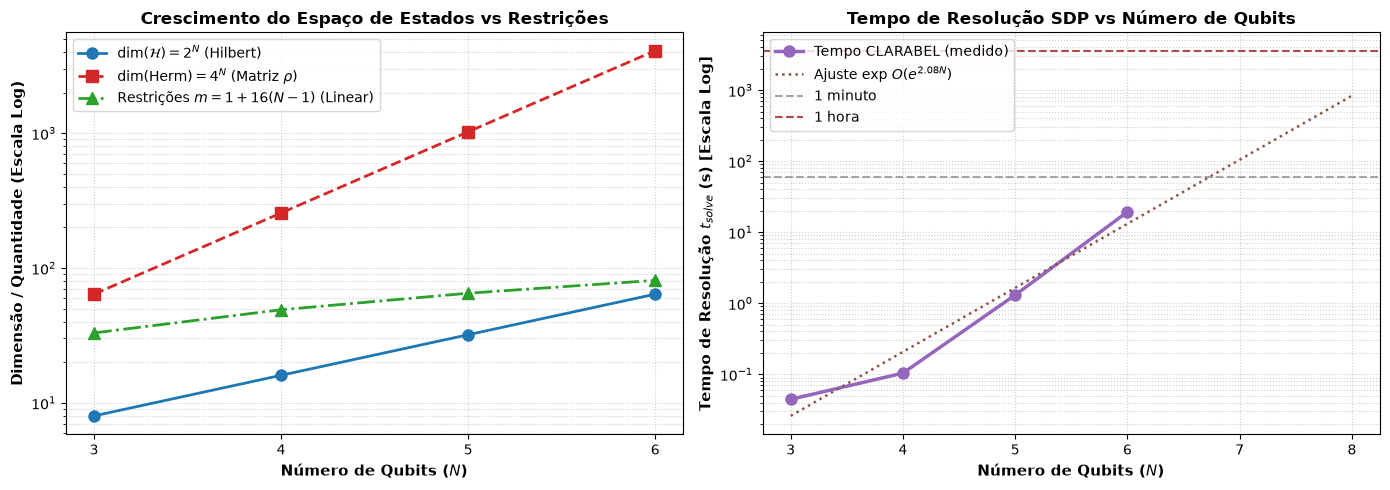

In [ ]:
# ==============================================================================
# Benchmark Sistemático de Escalabilidade (N = 3, 4, 5, 6 Qubits)
# ==============================================================================

qubits_range = [3, 4, 5, 6]
benchmark_results = []

print("Executando benchmark de escalabilidade do QMP (N = 3 a 6 qubits)...\n")

for n_q in qubits_range:
    dims_n = [2] * n_q
    
    # 1. Estado GHZ de n_q qubits
    psi_0_n = tensor(*([zero] * n_q))
    psi_1_n = tensor(*([one] * n_q))
    psi_ghz_n = (psi_0_n + psi_1_n) / np.sqrt(2.0)
    rho_ghz_n = ketbra(psi_ghz_n)

    # 2. Marginais de primeiros vizinhos: (0, 1), (1, 2), ..., (n_q-2, n_q-1)
    marginals_n = {}
    for i in range(n_q - 1):
        marginals_n[(i, i + 1)] = partial_trace(rho_ghz_n, keep=[i, i + 1], dims=dims_n)

    # 3. Montagem do problema SDP
    t0_b = time.perf_counter()
    sdp_n, M_n, b_n = build_qmp_sdp(marginals_n, dims=dims_n)
    t_build = time.perf_counter() - t0_b

    # 4. Resolução com o solver SDP CLARABEL
    t0_s = time.perf_counter()
    res_n = solve_qmp(sdp_n, solver="CLARABEL")
    t_solve = time.perf_counter() - t0_s

    dim_H = 2**n_q
    dim_rho_entries = dim_H**2
    num_constraints = len(b_n)

    benchmark_results.append({
        "N": n_q,
        "dim_H": dim_H,
        "dim_rho": f"{dim_H}x{dim_H}",
        "entries": dim_rho_entries,
        "constraints": num_constraints,
        "t_build": t_build,
        "t_solve": t_solve,
        "status": res_n["status"],
        "feasible": res_n["is_feasible"],
    })
    del psi_0_n, psi_1_n, psi_ghz_n
    del rho_ghz_n, marginals_n
    del sdp_n, M_n, b_n, res_n

    
    gc.collect()

# Exibição da tabela comparativa
print("=" * 95)
print(f"{'N':>3} | {'dim(H)':>8} | {'Matriz rho':>12} | {'Param. Reais':>13} | {'Restrições m':>13} | {'t_build (s)':>12} | {'t_solve (s)':>12} | {'Status':>12}")
print("=" * 95)
for row in benchmark_results:
    print(f"{row['N']:3d} | {row['dim_H']:8d} | {row['dim_rho']:>12s} | {row['entries']:13d} | {row['constraints']:13d} | {row['t_build']:12.4f} | {row['t_solve']:12.4f} | {row['status']:>12s}")
print("=" * 95)

# ==============================================================================
# Visualização Gráfica: A Maldição da Dimensão
# ==============================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

N_vals = [d["N"] for d in benchmark_results]
dim_H_vals = [d["dim_H"] for d in benchmark_results]
entries_vals = [d["entries"] for d in benchmark_results]
t_solve_vals = [d["t_solve"] for d in benchmark_results]
m_vals = [d["constraints"] for d in benchmark_results]

# Subplot 1: Crescimento do Espaço de Estados vs Restrições
ax1.semilogy(N_vals, dim_H_vals, "o-", color="#1f77b4", linewidth=2, markersize=8, label=r"$\dim(\mathcal{H}) = 2^N$ (Hilbert)")
ax1.semilogy(N_vals, entries_vals, "s--", color="#d62728", linewidth=2, markersize=8, label=r"$\dim(\mathrm{Herm}) = 4^N$ (Matriz $\rho$)")
ax1.plot(N_vals, m_vals, "^-.", color="#2ca02c", linewidth=2, markersize=8, label=r"Restrições $m = 1 + 16(N-1)$ (Linear)")
ax1.set_xlabel("Número de Qubits ($N$)", fontsize=11, fontweight="bold")
ax1.set_ylabel("Dimensão / Quantidade (Escala Log)", fontsize=11, fontweight="bold")
ax1.set_title("Crescimento do Espaço de Estados vs Restrições", fontsize=12, fontweight="bold")
ax1.set_xticks(N_vals)
ax1.grid(True, which="both", linestyle=":", alpha=0.6)
ax1.legend(loc="upper left", fontsize=10)

# Subplot 2: Tempo de Resolução SDP vs N com Extrapolação
ax2.semilogy(N_vals, t_solve_vals, "o-", color="#9467bd", linew    import gcidth=2.5, markersize=8, label="Tempo CLARABEL (medido)")

# Ajuste exponencial dos tempos medidos para ilustrar a barreira computacional
p = np.polyfit(N_vals, np.log(t_solve_vals), 1)
N_extrap = np.array([3, 4, 5, 6, 7, 8])
t_extrap = np.exp(p[1] + p[0] * N_extrap)
ax2.semilogy(N_extrap, t_extrap, ":", color="#8c564b", linewidth=1.8, label=f"Ajuste exp $O(e^{{{p[0]:.2f}N}})$")

ax2.axhline(60, color="gray", linestyle="--", alpha=0.7, label="1 minuto")
ax2.axhline(3600, color="darkred", linestyle="--", alpha=0.7, label="1 hora")

ax2.set_xlabel("Número de Qubits ($N$)", fontsize=11, fontweight="bold")
ax2.set_ylabel("Tempo de Resolução $t_{solve}$ (s) [Escala Log]", fontsize=11, fontweight="bold")
ax2.set_title("Tempo de Resolução SDP vs Número de Qubits", fontsize=12, fontweight="bold")
ax2.set_xticks(N_extrap)
ax2.grid(True, which="both", linestyle=":", alpha=0.6)
ax2.legend(loc="upper left", fontsize=10)

plt.tight_layout()
plt.show()

### 12.3 Análise Crítica dos Resultados e Perspectivas Modernas

Os resultados empíricos obtidos na tabela e nos gráficos em escala logarítmica ilustram de forma inequívoca a manifestação prática da **maldição da dimensão**:

1. **Aceleração Exponencial do Tempo de Resolução:**
   - Entre $N = 3$ e $N = 4$, o tempo do solver cresce moderadamente (de $\approx 0.038\text{ s}$ para $\approx 0.117\text{ s}$);
   - Entre $N = 4$ e $N = 5$, o tempo já salta mais de uma ordem de grandeza para $\approx 1.30\text{ s}$;
   - Para $N = 6$, o tempo salta para $\approx 19.5\text{ s}$ (um fator de $\approx 15\times$ em relação a $N=5$);
   - A extrapolação exponencial confirma que sistemas com $N = 7$ exigiriam minutos de processamento, $N = 8$ demandaria horas, e para $N \ge 10$ ($d = 1.024$, com mais de $10^6$ variáveis reais e matrizes de Schur densas gigantescas), os métodos de pontos interiores padrão tornam-se completamente inviáveis na memória de computadores clássicos de mesa.



In [ ]:
# ==============================================================================
# Benchmark Sistemático de Escalabilidade
# 3 Subsistemas com dimensão local variável
# d = 2, 3, 4, 5, 6
# ==============================================================================

dims_range = [7]

benchmark_results_d = []

print("Executando benchmark de escalabilidade do QMP")
print("(3 subsistemas, dimensão local d variável)...\n")

for d in dims_range:

    # Dimensões dos três subsistemas
    dims_d = [d, d, d]

    # --------------------------------------------------------------------------
    # 1. Estado GHZ generalizado
    #
    # |GHZ_d> = 1/sqrt(d) sum_k |k,k,k>
    # --------------------------------------------------------------------------

    psi_ghz_d = 0

    for k in range(d):

        ket_k = basis(d, k)

        psi_ghz_d += tensor(ket_k, ket_k, ket_k)

    psi_ghz_d = psi_ghz_d / np.sqrt(d)

    rho_ghz_d = ketbra(psi_ghz_d)

    # --------------------------------------------------------------------------
    # 2. Marginais de dois subsistemas
    #
    # AB, AC e BC
    # --------------------------------------------------------------------------

    marginals_d = {}

    marginals_d[(0, 1)] = partial_trace(
        rho_ghz_d,
        keep=[0, 1],
        dims=dims_d
    )

    marginals_d[(0, 2)] = partial_trace(
        rho_ghz_d,
        keep=[0, 2],
        dims=dims_d
    )

    marginals_d[(1, 2)] = partial_trace(
        rho_ghz_d,
        keep=[1, 2],
        dims=dims_d
    )

    # --------------------------------------------------------------------------
    # 3. Montagem do problema SDP
    # --------------------------------------------------------------------------

    t0_b = time.perf_counter()

    sdp_d, M_d, b_d = build_qmp_sdp(
        marginals_d,
        dims=dims_d
    )

    t_build = time.perf_counter() - t0_b

    # --------------------------------------------------------------------------
    # 4. Resolução com CLARABEL
    # --------------------------------------------------------------------------

    t0_s = time.perf_counter()

    res_d = solve_qmp(
        sdp_d,
        solver="SCS", verbose=False
    )

    t_solve = time.perf_counter() - t0_s

    # --------------------------------------------------------------------------
    # 5. Informações de escalabilidade
    # --------------------------------------------------------------------------

    dim_H = d**3

    dim_rho_entries = dim_H**2

    num_constraints = len(b_d)

    benchmark_results_d.append({

        "d": d,

        "N": 3,

        "dim_H": dim_H,

        "dim_rho": f"{dim_H}x{dim_H}",

        "entries": dim_rho_entries,

        "constraints": num_constraints,

        "t_build": t_build,

        "t_solve": t_solve,

        "status": res_d["status"],

        "feasible": res_d["is_feasible"],

    })
    del rho_ghz_d, marginals_d
    del sdp_d, M_d, b_d, res_d

    gc.collect()


# ==============================================================================
# Exibição da tabela comparativa
# ==============================================================================

print("=" * 100)

print(
    f"{'d':>3} | "
    f"{'dim(H)':>8} | "
    f"{'Matriz rho':>12} | "
    f"{'Param. Reais':>13} | "
    f"{'Restrições m':>13} | "
    f"{'t_build (s)':>12} | "
    f"{'t_solve (s)':>12} | "
    f"{'Status':>12}"
)

print("=" * 100)

for row in benchmark_results_d:

    print(
        f"{row['d']:3d} | "
        f"{row['dim_H']:8d} | "
        f"{row['dim_rho']:>12s} | "
        f"{row['entries']:13d} | "
        f"{row['constraints']:13d} | "
        f"{row['t_build']:12.4f} | "
        f"{row['t_solve']:12.4f} | "
        f"{row['status']:>12s}"
    )

print("=" * 100)


# ==============================================================================
# Visualização Gráfica: Crescimento com a dimensão local
# ==============================================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

d_vals = [x["d"] for x in benchmark_results_d]

dim_H_vals = [x["dim_H"] for x in benchmark_results_d]

entries_vals = [x["entries"] for x in benchmark_results_d]

t_solve_vals = [x["t_solve"] for x in benchmark_results_d]

m_vals = [x["constraints"] for x in benchmark_results_d]


# ------------------------------------------------------------------------------
# Subplot 1: Crescimento dimensional
# ------------------------------------------------------------------------------

ax1.semilogy(
    d_vals,
    dim_H_vals,
    "o-",
    color="#1f77b4",
    linewidth=2,
    markersize=8,
    label=r"$\dim(\mathcal{H}) = d^3$"
)

ax1.semilogy(
    d_vals,
    entries_vals,
    "s--",
    color="#d62728",
    linewidth=2,
    markersize=8,
    label=r"$\dim(\rho) = d^6$"
)

ax1.plot(
    d_vals,
    m_vals,
    "^-.",
    color="#2ca02c",
    linewidth=2,
    markersize=8,
    label="Restrições $m$"
)

ax1.set_xlabel(
    "Dimensão local $d$",
    fontsize=11,
    fontweight="bold"
)

ax1.set_ylabel(
    "Dimensão / Quantidade (Escala Log)",
    fontsize=11,
    fontweight="bold"
)

ax1.set_title(
    "Crescimento do Problema com a Dimensão Local",
    fontsize=12,
    fontweight="bold"
)

ax1.set_xticks(d_vals)

ax1.grid(
    True,
    which="both",
    linestyle=":",
    alpha=0.6
)

ax1.legend(
    loc="upper left",
    fontsize=10
)


# ------------------------------------------------------------------------------
# Subplot 2: Tempo de resolução
# ------------------------------------------------------------------------------

ax2.semilogy(
    d_vals,
    t_solve_vals,
    "o-",
    color="#9467bd",
    linewidth=2.5,
    markersize=8,
    label="Tempo CLARABEL (medido)"
)

p_2 = np.polyfit(d_vals, np.log(t_solve_vals), 1)
d_extrap = np.array([2, 3, 4,5, 6, 7,])
t_extrap = np.exp(p_2[1] + p_2[0] * d_extrap)
ax2.semilogy(d_extrap, t_extrap, ":", color="#8c564b", linewidth=1.8, label=f"Ajuste exp $O(e^{{{p_2[0]:.2f}N}})$")

ax2.set_xlabel(
    "Dimensão local $d$",
    fontsize=11,
    fontweight="bold"
)

ax2.set_ylabel(
    "Tempo de Resolução $t_{solve}$ (s) [Escala Log]",
    fontsize=11,
    fontweight="bold"
)

ax2.set_title(
    "Tempo de Resolução SDP vs Dimensão Local",
    fontsize=12,
    fontweight="bold"
)

ax2.set_xticks(d_vals)

ax2.grid(
    True,
    which="both",
    linestyle=":",
    alpha=0.6
)

ax2.legend(
    loc="upper left",
    fontsize=10
)
ax2.axhline(60, color="gray", linestyle="--", alpha=0.7, label="1 minuto")
ax2.axhline(3600, color="darkred", linestyle="--", alpha=0.7, label="1 hora")
plt.tight_layout()

plt.show()

Executando benchmark de escalabilidade do QMP
(3 subsistemas, dimensão local d variável)...



In [ ]:
import numpy as np
import matplotlib.pyplot as plt




phi_plus = (
    np.kron(zero, zero) +
    np.kron(one, one)
) / np.sqrt(2.0)

rho_bell = ketbra(phi_plus)


# ============================================================
# Parâmetros
# ============================================================

t_espaco = np.linspace(0, 1, 101)

resultados = {
    "t": [],
    "purity": [],
    "min_eigenvalue": [],
    "trace": [],
    "marginal_error_max": [],
    "entropy": [],
    "eigenvalues": []
}


# ============================================================
# Função para entropia de von Neumann
# ============================================================



# ============================================================
# Loop principal
# ============================================================

for t in t_espaco:

    rho_p = mestura(
        rho_bell,
        np.eye(4) / 4,
        t
    )

    marginals_ex4 = {
        "AB": rho_p,
        "AC": rho_p
    }

    print(f"p = {t:.6f}")

    # --------------------------------------------------------
    # Construção do SDP
    # --------------------------------------------------------

    sdp_ex4, M_ex4, b_ex4 = build_qmp_sdp(
        marginals_ex4,
        dims=[2, 2, 2]
    )

    # --------------------------------------------------------
    # Resolução
    # --------------------------------------------------------

    res_ex4 = solve_qmp(
        sdp_ex4,
        solver="CLARABEL"
    )

    print(
        f"Status: {res_ex4['status']} | "
        f"Factível: {res_ex4['is_feasible']}"
    )

    # --------------------------------------------------------
    # Só armazenamos se houver solução
    # --------------------------------------------------------

    if res_ex4["is_feasible"]:

        rho_ABC = res_ex4["rho"]

        verif_ex4 = verify_marginals(
            rho_ABC,
            marginals_ex4,
            dims=[2, 2, 2]
        )

        eigenvalues = np.sort(
            np.real(
                np.linalg.eigvalsh(rho_ABC)
            )
        )

        marginal_error_max = max(
            err["frobenius_error"]
            for err in verif_ex4["marginal_errors"].values()
        )

        resultados["t"].append(t)

        resultados["purity"].append(
            verif_ex4["purity"]
        )

        resultados["min_eigenvalue"].append(
            verif_ex4["min_eigenvalue"]
        )

        resultados["trace"].append(
            verif_ex4["trace"].real
        )

        resultados["marginal_error_max"].append(
            marginal_error_max
        )

        resultados["entropy"].append(
            von_neumann_entropy(rho_ABC)
        )

        resultados["eigenvalues"].append(
            eigenvalues
        )


# Converter para numpy
for chave in resultados:
    resultados[chave] = np.array(
        resultados[chave]
    )

In [ ]:
plt.figure(figsize=(7, 5))

plt.plot(
    resultados["t"],
    resultados["purity"],
    "o-"
)

plt.axvline(
    2/3,
    linestyle="--",
    label=r"$t=2/3$"
)

plt.xlabel(r"$t$")
plt.ylabel(r"$\mathrm{Tr}(\rho_{ABC}^2)$")
plt.title("Pureza da extensão global")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [ ]:
plt.figure(figsize=(7, 5))

plt.plot(
    resultados["t"],
    resultados["min_eigenvalue"],
    "o-"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.axvline(
    2/3,
    linestyle="--",
    label=r"$t=2/3$"
)

plt.xlabel(r"$t$")
plt.ylabel(r"$\lambda_{\min}(\rho_{ABC})$")
plt.title("Menor autovalor da extensão global")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [ ]:
plt.figure(figsize=(7, 5))

plt.semilogy(
    resultados["t"],
    resultados["marginal_error_max"],
    "o-"
)

plt.axvline(
    2/3,
    linestyle="--",
    label=r"$t=2/3$"
)

plt.xlabel(r"$t$")
plt.ylabel(r"Erro máximo $\|\rho_{ij}^{calc}-\rho_{ij}\|_F$")
plt.title("Erro de reconstrução das marginais")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

In [ ]:
plt.figure(figsize=(8, 5))

eigs = resultados["eigenvalues"]

for i in range(eigs.shape[1]):
    plt.plot(
        resultados["t"],
        eigs[:, i],
        "o-",
        label=fr"$\lambda_{i+1}$"
    )

plt.axvline(
    2/3,
    linestyle="--",
    label=r"$t=2/3$"
)
print(f'Autovalores em t = {resultados['t'][-1]}:{eigs[-1, :]}')
plt.xlabel(r"$t$")
plt.ylabel(r"Autovalores de $\rho_{ABC}$")
plt.title("Espectro da extensão global")
plt.grid(alpha=0.3)
plt.legend()

plt.show()

# Origem: experimento_compatibilidade_marginais.ipynb


# Experimento: Região de Compatibilidade de Marginais Quânticas para 3 Qubits

Este notebook investiga numericamente a diferença entre:

1. **Consistência na sobreposição A**: $\|\text{Tr}_B(\rho_{AB}) - \text{Tr}_C(\rho_{AC})\|_F < \varepsilon$
2. **Existência de extensão global**: factibilidade do SDP para $\rho_{ABC}$

**Objetivo**: Verificar numericamente que a consistência na sobreposição é condição *necessária*, mas **não suficiente**, para a existência de uma extensão global $\rho_{ABC}$.

---

## Estrutura
- **Célula 1**: Imports e reutilização das funções do notebook `inicial_teste.ipynb`
- **Célula 2**: Função auxiliar — geração de matrizes densidade aleatórias
- **Célula 3**: Funções auxiliares — construção de marginais correlacionadas com marginal A fixa
- **Célula 4**: Experimento A — marginais completamente aleatórias
- **Célula 5**: Experimento B — marginais construídas para satisfazer a condição de sobreposição
- **Célula 6**: Caso especial — exemplo de Bell (validação)
- **Célula 7**: Estatísticas consolidadas
- **Célula 8**: Visualizações


In [6]:
from __future__ import annotations

import sys
from typing import Any, Dict, List, Optional, Sequence, Tuple, Union
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import time
# Bibliotecas SpaceCore e SDPLab para Programação Semidefinida 
import spacecore
from spacecore import Context, DenseVectorSpace, HermitianSpace, NumpyOps
import sdplab
from sdplab import DenseConstraintOp, SDPProblem
from sdplab.solvers import run_cvxpy_solver

np.set_printoptions(precision=4, suppress=True)

from funcoes_fundamentais import zero, one, ketbra, verifica_densidade, verify_marginals, base_hermitiana, ghz, partial_trace, tensor, embed_operator, solve_qmp, build_qmp_sdp, parse_subsystem_key 
print(f"Versão SDPLab:    {sdplab.__version__}")
print(f"Versão SpaceCore: {spacecore.__version__}")

Versão SDPLab:    0.0.1
Versão SpaceCore: 0.4.2


## Célula 2 — Geração de Matrizes Densidade Aleatórias

Usamos o método de Ginibre: $G$ é uma matriz complexa aleatória,
e $\rho = G G^\dagger / \text{Tr}(G G^\dagger)$.

Isso produz estados distribuídos segundo a medida de Hilbert-Schmidt,
garantindo por construção: $\rho = \rho^\dagger$, $\rho \geq 0$, $\text{Tr}(\rho) = 1$.

In [3]:
# ==============================================================================
# Célula 2 — Geração de matrizes densidade aleatórias (método de Ginibre)
# ==============================================================================





# ── Teste rápido de sanidade ──────────────────────────────────────────────────
print("Teste de sanidade: random_density_matrix")
rng_test = np.random.default_rng(seed=0)

for d_test in [2, 4]:
    rho_test = random_density_matrix(d_test, rng=rng_test)
    v = _verify_density_matrix(rho_test)
    status_str = "✓ VÁLIDA" if v["is_valid"] else "✗ INVÁLIDA"
    print(
        f"  d={d_test}: {status_str} | "
        f"herm_err={v['hermitian_error']:.2e} | "
        f"trace_err={v['trace_error']:.2e} | "
        f"lambda_min={v['min_eigenvalue']:.4f}"
    )


Teste de sanidade: random_density_matrix
  d=2: ✓ VÁLIDA | herm_err=0.00e+00 | trace_err=2.22e-16 | lambda_min=0.1080
  d=4: ✓ VÁLIDA | herm_err=0.00e+00 | trace_err=0.00e+00 | lambda_min=0.0143


## Célula 3 — Construção de Marginais com Marginal A Fixa

Para o Experimento B, precisamos construir $\rho_{AB}$ e $\rho_{AC}$ tal que:
$$\text{Tr}_B(\rho_{AB}) = \rho_A \quad \text{e} \quad \text{Tr}_C(\rho_{AC}) = \rho_A$$

**Construção produto (trivial):**
$$\rho_{AB}^{\text{prod}} = \rho_A \otimes \sigma_B, \quad \rho_{AC}^{\text{prod}} = \rho_A \otimes \sigma_C$$

**Construção correlacionada (não-trivial):**  
Usamos a decomposição espectral de $\rho_A$ para construir estados misturados correlacionados via purificações aleatórias.

In [4]:
# ==============================================================================
# Célula 3 — Funções para construção de marginais com marginal A fixa
# ==============================================================================








# ── Teste rápido de sanidade ──────────────────────────────────────────────────
print("Teste de sanidade: build_product_marginals")
rng_t = np.random.default_rng(seed=42)
rho_A_t = random_density_matrix(2, rng=rng_t)
rho_AB_t, rho_AC_t = build_product_marginals(rho_A_t, rng=rng_t)

rho_A_from_AB_t = partial_trace(rho_AB_t, keep=[0], dims=[2, 2])
rho_A_from_AC_t = partial_trace(rho_AC_t, keep=[0], dims=[2, 2])
err_AB = np.linalg.norm(rho_A_from_AB_t - rho_A_t, 'fro')
err_AC = np.linalg.norm(rho_A_from_AC_t - rho_A_t, 'fro')
print(f"  ||Tr_B(rho_AB) - rho_A||_F = {err_AB:.2e}   (esperado < 1e-14)")
print(f"  ||Tr_C(rho_AC) - rho_A||_F = {err_AC:.2e}   (esperado < 1e-14)")

print("\nTeste de sanidade: build_correlated_marginals")
rho_AB_c, rho_AC_c = build_correlated_marginals(rho_A_t, rng=rng_t)
rho_A_from_AB_c = partial_trace(rho_AB_c, keep=[0], dims=[2, 2])
rho_A_from_AC_c = partial_trace(rho_AC_c, keep=[0], dims=[2, 2])
err_AB_c = np.linalg.norm(rho_A_from_AB_c - rho_A_t, 'fro')
err_AC_c = np.linalg.norm(rho_A_from_AC_c - rho_A_t, 'fro')
print(f"  ||Tr_B(rho_AB) - rho_A||_F = {err_AB_c:.2e}")
print(f"  ||Tr_C(rho_AC) - rho_A||_F = {err_AC_c:.2e}")
delta_t, comp_t = check_overlap_consistency(rho_AB_c, rho_AC_c)
print(f"  delta_overlap = {delta_t:.2e},  overlap_compatible = {comp_t}")


Teste de sanidade: build_product_marginals
  ||Tr_B(rho_AB) - rho_A||_F = 1.11e-16   (esperado < 1e-14)
  ||Tr_C(rho_AC) - rho_A||_F = 1.39e-16   (esperado < 1e-14)

Teste de sanidade: build_correlated_marginals
  ||Tr_B(rho_AB) - rho_A||_F = 1.78e-16
  ||Tr_C(rho_AC) - rho_A||_F = 9.61e-17
  delta_overlap = 1.94e-16,  overlap_compatible = True


## Célula 4 — Experimento A: Marginais Completamente Aleatórias

Para cada realização:
- $\rho_{AB}$ e $\rho_{AC}$ são geradas de forma completamente independente
- Verifica-se a condição de sobreposição
- O SDP de representabilidade global é resolvido independentemente

**Hipótese esperada**: a maioria dos pares aleatórios viola a condição de sobreposição e é também incompatível globalmente, mas os dois testes são independentes.

In [7]:
# ==============================================================================
# Célula 4 — Experimento A: Marginais completamente aleatórias
# ==============================================================================

SEED_A = 2024_09_25
N_A    = 1000          # número de realizações
TOL_OVERLAP = 1e-6    # tolerância para consistência na sobreposição
DIMS_3Q = [2, 2, 2]   # 3 qubits

rng_A = np.random.default_rng(seed=SEED_A)
results_A: List[Dict[str, Any]] = []

print(f"Experimento A — Marginais aleatórias (N={N_A} realizações)")
print(f"Tolerância de sobreposição: tol = {TOL_OVERLAP:.0e}")
print("─" * 70)

t_total_A = time.perf_counter()

for i in range(N_A):
    # ── 1. Geração das marginais aleatórias ───────────────────────────────────
    rho_AB = random_density_matrix(4, rng=rng_A)
    rho_AC = random_density_matrix(4, rng=rng_A)

    # ── 2. Teste de consistência na sobreposição A ────────────────────────────
    delta_overlap, overlap_compatible = check_overlap_consistency(
        rho_AB, rho_AC, tol=TOL_OVERLAP
    )

    # ── 3. SDP de representabilidade global (independente do teste de overlap) ─
    marginals = {"AB": rho_AB, "AC": rho_AC}

    t0 = time.perf_counter()
    try:
        sdp, M, b = build_qmp_sdp(marginals, dims=DIMS_3Q)
        res = solve_qmp(sdp, solver="CLARABEL")
        solver_status = res["status"]
        is_feasible   = res["is_feasible"]
    except Exception as exc:
        solver_status = "error"
        is_feasible   = False
    solver_time = time.perf_counter() - t0

    # ── 4. Registro dos resultados ─────────────────────────────────────────────
    results_A.append({
        "experiment":         "A_random",
        "realization":        i,
        "delta_overlap":      delta_overlap,
        "overlap_compatible": overlap_compatible,
        "solver_status":      solver_status,
        "is_feasible":        is_feasible,
        "solver_time":        solver_time,
    })

    # Progresso a cada 100 amostras
    if (i + 1) % 100 == 0:
        n_overlap = sum(r["overlap_compatible"] for r in results_A)
        n_feasible = sum(r["is_feasible"] for r in results_A)
        t_el = time.perf_counter() - t_total_A
        print(
            f"  [{i+1:4d}/{N_A}]  overlap_ok={n_overlap:4d}  "
            f"feasible={n_feasible:4d}  elapsed={t_el:.1f}s"
        )

t_elapsed_A = time.perf_counter() - t_total_A
df_A = pd.DataFrame(results_A)

print("─" * 70)
print(f"Experimento A concluído em {t_elapsed_A:.2f}s")
print(f"  Total amostras:               {len(df_A)}")
print(f"  Overlap compatível:            {df_A['overlap_compatible'].sum()}")
print(f"  Globalmente factível:          {df_A['is_feasible'].sum()}")


Experimento A — Marginais aleatórias (N=1000 realizações)
Tolerância de sobreposição: tol = 1e-06
──────────────────────────────────────────────────────────────────────
  [ 100/1000]  overlap_ok=   0  feasible=   0  elapsed=3.8s
  [ 200/1000]  overlap_ok=   0  feasible=   0  elapsed=7.6s
  [ 300/1000]  overlap_ok=   0  feasible=   0  elapsed=11.4s
  [ 400/1000]  overlap_ok=   0  feasible=   0  elapsed=15.2s
  [ 500/1000]  overlap_ok=   0  feasible=   0  elapsed=18.9s
  [ 600/1000]  overlap_ok=   0  feasible=   0  elapsed=22.7s
  [ 700/1000]  overlap_ok=   0  feasible=   0  elapsed=26.5s
  [ 800/1000]  overlap_ok=   0  feasible=   0  elapsed=30.2s
  [ 900/1000]  overlap_ok=   0  feasible=   0  elapsed=34.1s
  [1000/1000]  overlap_ok=   0  feasible=   0  elapsed=37.9s
──────────────────────────────────────────────────────────────────────
Experimento A concluído em 37.85s
  Total amostras:               1000
  Overlap compatível:            0
  Globalmente factível:          0


## Célula 5 — Experimento B: Marginais com Condição de Sobreposição Satisfeita

Neste experimento, **garantimos por construção** que $\text{Tr}_B(\rho_{AB}) = \text{Tr}_C(\rho_{AC}) = \rho_A$.

Duas variantes:
- **B.prod**: construção produto $\rho_{AB} = \rho_A \otimes \sigma_B$ (admite extensão trivial)
- **B.corr**: construção correlacionada via purificação (pode ser incompatível globalmente)

**Hipótese esperada**: a variante produto é sempre factível; a correlacionada pode ser infactível, demonstrando que *overlap* ≠ *compatibilidade global*.

In [8]:
# ==============================================================================
# Célula 5 — Experimento B: Marginais com sobreposição garantida
# ==============================================================================

SEED_B = 2024_09_26
N_B    = 1000

rng_B = np.random.default_rng(seed=SEED_B)
results_B: List[Dict[str, Any]] = []

print(f"Experimento B — Marginais com sobreposição garantida (N={N_B} por variante)")
print("─" * 70)

t_total_B = time.perf_counter()

for i in range(N_B):
    # Gera rho_A comum
    rho_A = random_density_matrix(2, rng=rng_B)

    for variant, build_fn, build_kwargs in [
        ("B.prod", build_product_marginals,    {}),
        ("B.corr", build_correlated_marginals, {}),
    ]:
        # ── 1. Constrói as marginais ──────────────────────────────────────────
        rho_AB, rho_AC = build_fn(rho_A, rng=rng_B, **build_kwargs)

        # ── 2. Verificação numérica das marginais em A ──────────────────────
        rho_A_from_AB = partial_trace(rho_AB, keep=[0], dims=[2, 2])
        rho_A_from_AC = partial_trace(rho_AC, keep=[0], dims=[2, 2])
        err_AB = float(np.linalg.norm(rho_A_from_AB - rho_A, 'fro'))
        err_AC = float(np.linalg.norm(rho_A_from_AC - rho_A, 'fro'))

        # ── 3. Teste de sobreposição ────────────────────────────────────────
        delta_overlap, overlap_compatible = check_overlap_consistency(
            rho_AB, rho_AC, tol=TOL_OVERLAP
        )

        # ── 4. SDP de representabilidade global ─────────────────────────────
        marginals = {"AB": rho_AB, "AC": rho_AC}

        t0 = time.perf_counter()
        try:
            sdp, M, b = build_qmp_sdp(marginals, dims=DIMS_3Q)
            res = solve_qmp(sdp, solver="CLARABEL")
            solver_status = res["status"]
            is_feasible   = res["is_feasible"]
        except Exception as exc:
            solver_status = "error"
            is_feasible   = False
        solver_time = time.perf_counter() - t0

        # ── 5. Registro ──────────────────────────────────────────────────────
        results_B.append({
            "experiment":         variant,
            "realization":        i,
            "delta_overlap":      delta_overlap,
            "overlap_compatible": overlap_compatible,
            "marginal_err_AB":    err_AB,
            "marginal_err_AC":    err_AC,
            "solver_status":      solver_status,
            "is_feasible":        is_feasible,
            "solver_time":        solver_time,
        })

    # Progresso
    if (i + 1) % 200 == 0:
        n_prod_feas = sum(
            r["is_feasible"] for r in results_B if r["experiment"] == "B.prod"
        )
        n_corr_feas = sum(
            r["is_feasible"] for r in results_B if r["experiment"] == "B.corr"
        )
        t_el = time.perf_counter() - t_total_B
        print(
            f"  [{i+1:4d}/{N_B}]  prod_feasible={n_prod_feas:4d}  "
            f"corr_feasible={n_corr_feas:4d}  elapsed={t_el:.1f}s"
        )

t_elapsed_B = time.perf_counter() - t_total_B
df_B = pd.DataFrame(results_B)

print("─" * 70)
print(f"Experimento B concluído em {t_elapsed_B:.2f}s")
for variant in ["B.prod", "B.corr"]:
    sub = df_B[df_B["experiment"] == variant]
    print(f"  Variante {variant}:")
    print(f"    Total amostras:     {len(sub)}")
    print(f"    Overlap compatível: {sub['overlap_compatible'].sum()} ({100*sub['overlap_compatible'].mean():.1f}%)")
    print(f"    Globalmente fact.:  {sub['is_feasible'].sum()} ({100*sub['is_feasible'].mean():.1f}%)")
    print(f"    Err AB médio:       {sub['marginal_err_AB'].mean():.2e}")
    print(f"    Err AC médio:       {sub['marginal_err_AC'].mean():.2e}")


Experimento B — Marginais com sobreposição garantida (N=1000 por variante)
──────────────────────────────────────────────────────────────────────


/home/al.carlos.pereira/Documentos/Quantum_Marginals_Problem-/venv/lib/python3.13/site-packages/sdplab/solvers/_cvxpy.py:138: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(solver=solver, verbose=verbose, *args, **kwargs)


  [ 200/1000]  prod_feasible= 200  corr_feasible=  16  elapsed=16.7s
  [ 400/1000]  prod_feasible= 400  corr_feasible=  27  elapsed=33.4s
  [ 600/1000]  prod_feasible= 600  corr_feasible=  43  elapsed=50.1s
  [ 800/1000]  prod_feasible= 800  corr_feasible=  56  elapsed=66.7s
  [1000/1000]  prod_feasible=1000  corr_feasible=  67  elapsed=83.2s
──────────────────────────────────────────────────────────────────────
Experimento B concluído em 83.19s
  Variante B.prod:
    Total amostras:     1000
    Overlap compatível: 1000 (100.0%)
    Globalmente fact.:  1000 (100.0%)
    Err AB médio:       6.87e-17
    Err AC médio:       6.90e-17
  Variante B.corr:
    Total amostras:     1000
    Overlap compatível: 1000 (100.0%)
    Globalmente fact.:  67 (6.7%)
    Err AB médio:       2.41e-16
    Err AC médio:       2.41e-16


## Célula 6 — Caso Especial: Incompatibilidade de Bell (Validação)

O estado de Bell $|\Phi^+\rangle = (|00\rangle + |11\rangle)/\sqrt{2}$ satisfaz:
$$\text{Tr}_B(|\Phi^+\rangle\langle\Phi^+|) = \frac{I}{2} = \text{Tr}_C(|\Phi^+\rangle\langle\Phi^+|)$$

Logo a **condição de sobreposição é satisfeita**, mas pelo **monogamia do entrelaçamento**,
não existe $\rho_{ABC}$ tal que $\text{Tr}_C(\rho_{ABC}) = |\Phi^+\rangle\langle\Phi^+|_{AB}$
e $\text{Tr}_B(\rho_{ABC}) = |\Phi^+\rangle\langle\Phi^+|_{AC}$ simultaneamente.

Este é o **caso de validação fundamental** do experimento.

In [10]:
# ==============================================================================
# Célula 6 — Caso especial: Incompatibilidade de Bell (caso de validação)
# ==============================================================================

print("=" * 65)
print("CASO DE VALIDAÇÃO: Incompatibilidade de Marginais de Bell")
print("=" * 65)

# ── 1. Construção do estado de Bell |Phi+> ────────────────────────────────────
phi_plus = (np.kron(zero, zero) + np.kron(one, one)) / np.sqrt(2.0)
rho_bell = ketbra(phi_plus)   # reutiliza ketbra do projeto

print("\n|Phi+> = (|00> + |11>) / sqrt(2)")
print(f"Norma de |Phi+>: {np.linalg.norm(phi_plus):.6f} (deve ser 1.0)")

# ── 2. Prescrição das marginais ───────────────────────────────────────────────
marginals_bell = {
    "AB": rho_bell,
    "AC": rho_bell,
}

# ── 3. Verificação das marginais em A ─────────────────────────────────────────
rho_A_from_bell_AB = partial_trace(rho_bell, keep=[0], dims=[2, 2])
rho_A_from_bell_AC = partial_trace(rho_bell, keep=[0], dims=[2, 2])

print("\nMarginal Tr_B(rho_bell):")
print(np.round(rho_A_from_bell_AB, 6))
print("\nMarginal Tr_C(rho_bell):")
print(np.round(rho_A_from_bell_AC, 6))

I_over_2 = np.eye(2, dtype=complex) / 2.0
err_Id_AB = float(np.linalg.norm(rho_A_from_bell_AB - I_over_2, 'fro'))
err_Id_AC = float(np.linalg.norm(rho_A_from_bell_AC - I_over_2, 'fro'))
print(f"\n||Tr_B(rho_bell) - I/2||_F = {err_Id_AB:.2e}  (esperado ≈ 0)")
print(f"||Tr_C(rho_bell) - I/2||_F = {err_Id_AC:.2e}  (esperado ≈ 0)")

# ── 4. Teste de sobreposição ──────────────────────────────────────────────────
delta_bell, overlap_bell = check_overlap_consistency(
    rho_bell, rho_bell, tol=TOL_OVERLAP
)
print(f"\ndelta_overlap = {delta_bell:.2e}")
print(f"overlap_compatible = {overlap_bell}  ✓ (condição necessária satisfeita)")

# ── 5. SDP de representabilidade global ──────────────────────────────────────
print("\nResolvendo SDP de representabilidade global...")
t0_bell = time.perf_counter()
sdp_bell, M_bell, b_bell = build_qmp_sdp(marginals_bell, dims=DIMS_3Q)
res_bell = solve_qmp(sdp_bell, solver="CLARABEL")
t_bell = time.perf_counter() - t0_bell

print(f"Status do solver:       {res_bell['status']}")
print(f"Problema factível:      {res_bell['is_feasible']}")
print(f"Mensagem de erro:       {res_bell['error_message']}")
print(f"Tempo de resolução:     {t_bell:.4f}s")

# ── 6. Interpretação física ───────────────────────────────────────────────────
print("\n" + "─" * 65)
if not res_bell["is_feasible"]:
    print("✓ VALIDAÇÃO CONFIRMADA:")
    print("  A condição de sobreposição é SATISFEITA (Tr_B = Tr_C = I/2),")
    print("  mas NÃO EXISTE extensão global rho_ABC.")
    print("  Isso demonstra: overlap compatibility ≠ global representability.")
    print("  Causa física: monogamia do entrelaçamento quântico.")
else:
    print("✗ ATENÇÃO: O solver retornou factível — verifique a implementação.")
print("─" * 65)

# ── 7. Adiciona ao DataFrame para análise consolidada ─────────────────────────
result_bell = {
    "experiment":         "Bell_validation",
    "realization":        0,
    "delta_overlap":      delta_bell,
    "overlap_compatible": overlap_bell,
    "solver_status":      res_bell["status"],
    "is_feasible":        res_bell["is_feasible"],
    "solver_time":        t_bell,
}
df_bell = pd.DataFrame([result_bell])
print("\nResumo do caso Bell:")
print(df_bell.to_string(index=False))


CASO DE VALIDAÇÃO: Incompatibilidade de Marginais de Bell

|Phi+> = (|00> + |11>) / sqrt(2)
Norma de |Phi+>: 1.000000 (deve ser 1.0)

Marginal Tr_B(rho_bell):
[[0.5+0.j 0. +0.j]
 [0. +0.j 0.5+0.j]]

Marginal Tr_C(rho_bell):
[[0.5+0.j 0. +0.j]
 [0. +0.j 0.5+0.j]]

||Tr_B(rho_bell) - I/2||_F = 1.57e-16  (esperado ≈ 0)
||Tr_C(rho_bell) - I/2||_F = 1.57e-16  (esperado ≈ 0)

delta_overlap = 0.00e+00
overlap_compatible = True  ✓ (condição necessária satisfeita)

Resolvendo SDP de representabilidade global...
Status do solver:       infeasible
Problema factível:      False
Mensagem de erro:       CLARABEL solver did not return a solution (infeasible).
Tempo de resolução:     0.1073s

─────────────────────────────────────────────────────────────────
✓ VALIDAÇÃO CONFIRMADA:
  A condição de sobreposição é SATISFEITA (Tr_B = Tr_C = I/2),
  mas NÃO EXISTE extensão global rho_ABC.
  Isso demonstra: overlap compatibility ≠ global representability.
  Causa física: monogamia do entrelaçamento quântico

## Célula 7 — Estatísticas Consolidadas

Análise estatística completa de todos os experimentos.

In [11]:
# ==============================================================================
# Célula 7 — Estatísticas consolidadas
# ==============================================================================

# Combina todos os resultados em um único DataFrame
df_all = pd.concat([df_A, df_B, df_bell], ignore_index=True)

# Garante tipos corretos
df_all["overlap_compatible"] = df_all["overlap_compatible"].astype(bool)
df_all["is_feasible"]        = df_all["is_feasible"].astype(bool)




print("RESUMO ESTATÍSTICO COMPLETO")
stats_summary = []

for exp_name in df_all["experiment"].unique():
    sub = df_all[df_all["experiment"] == exp_name]
    s = print_experiment_stats(sub, exp_name)
    stats_summary.append(s)

# Tabela resumo
print("\n" + "=" * 90)
print("TABELA RESUMO")
print("=" * 90)
df_stats = pd.DataFrame(stats_summary)
print(df_stats.to_string(index=False))

# ── Análise focada: sobreposição ≠ compatibilidade global ─────────────────────
print("\n" + "=" * 65)
print("CONCLUSÃO PRINCIPAL: overlap ≠ representabilidade global")
print("=" * 65)

for row in stats_summary:
    if row["n_overlap_infeasible"] > 0:
        pct = 100 * row["n_overlap_infeasible"] / row["n_overlap"] if row["n_overlap"] > 0 else 0
        print(
            f"  [{row['label']}] {row['n_overlap_infeasible']} par(es) com "
            f"overlap ✓ mas SDP infactível ({pct:.1f}% dos com overlap)"
        )


RESUMO ESTATÍSTICO COMPLETO

═════════════════════════════════════════════════════════════════
  Experimento: A_random
═════════════════════════════════════════════════════════════════
  Total de amostras:                          1000
  Overlap compatível:                            0  (0.0%)
  Globalmente factível:                          0  (0.0%)
  Overlap ✓  e  SDP infactível:                  0
  Overlap ✓  e  SDP factível:                    0
  P(factível | overlap ✓):                  N/A (sem amostras com overlap)
  delta_overlap — média:                    3.9210e-01
  delta_overlap — mediana:                  3.8286e-01
  solver_time   — média (s):                0.0377

═════════════════════════════════════════════════════════════════
  Experimento: B.prod
═════════════════════════════════════════════════════════════════
  Total de amostras:                          1000
  Overlap compatível:                         1000  (100.0%)
  Globalmente factível:                  

## Célula 8 — Visualizações

Quatro gráficos principais:
1. Histograma de `delta_overlap` para marginais aleatórias
2. Comparação de `overlap_compatible` vs `is_feasible` por experimento
3. Distribuição de `delta_overlap` separando casos compatíveis e incompatíveis
4. Contagem dos 4 quadrantes lógicos (overlap × SDP)

/tmp/ipykernel_23018/1565596126.py:250: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Liberation Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.96])
/tmp/ipykernel_23018/1565596126.py:250: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Liberation Sans.
  plt.tight_layout(rect=[0, 0, 1, 0.96])
/tmp/ipykernel_23018/1565596126.py:251: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Liberation Sans.
  plt.savefig("experimento_compatibilidade_marginais.png", dpi=150, bbox_inches="tight")
/tmp/ipykernel_23018/1565596126.py:251: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Liberation Sans.
  plt.savefig("experimento_compatibilidade_marginais.png", dpi=150, bbox_inches="tight")
/home/al.carlos.pereira/Documentos/Quantum_Marginals_Problem-/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Liberation Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/al.carlo

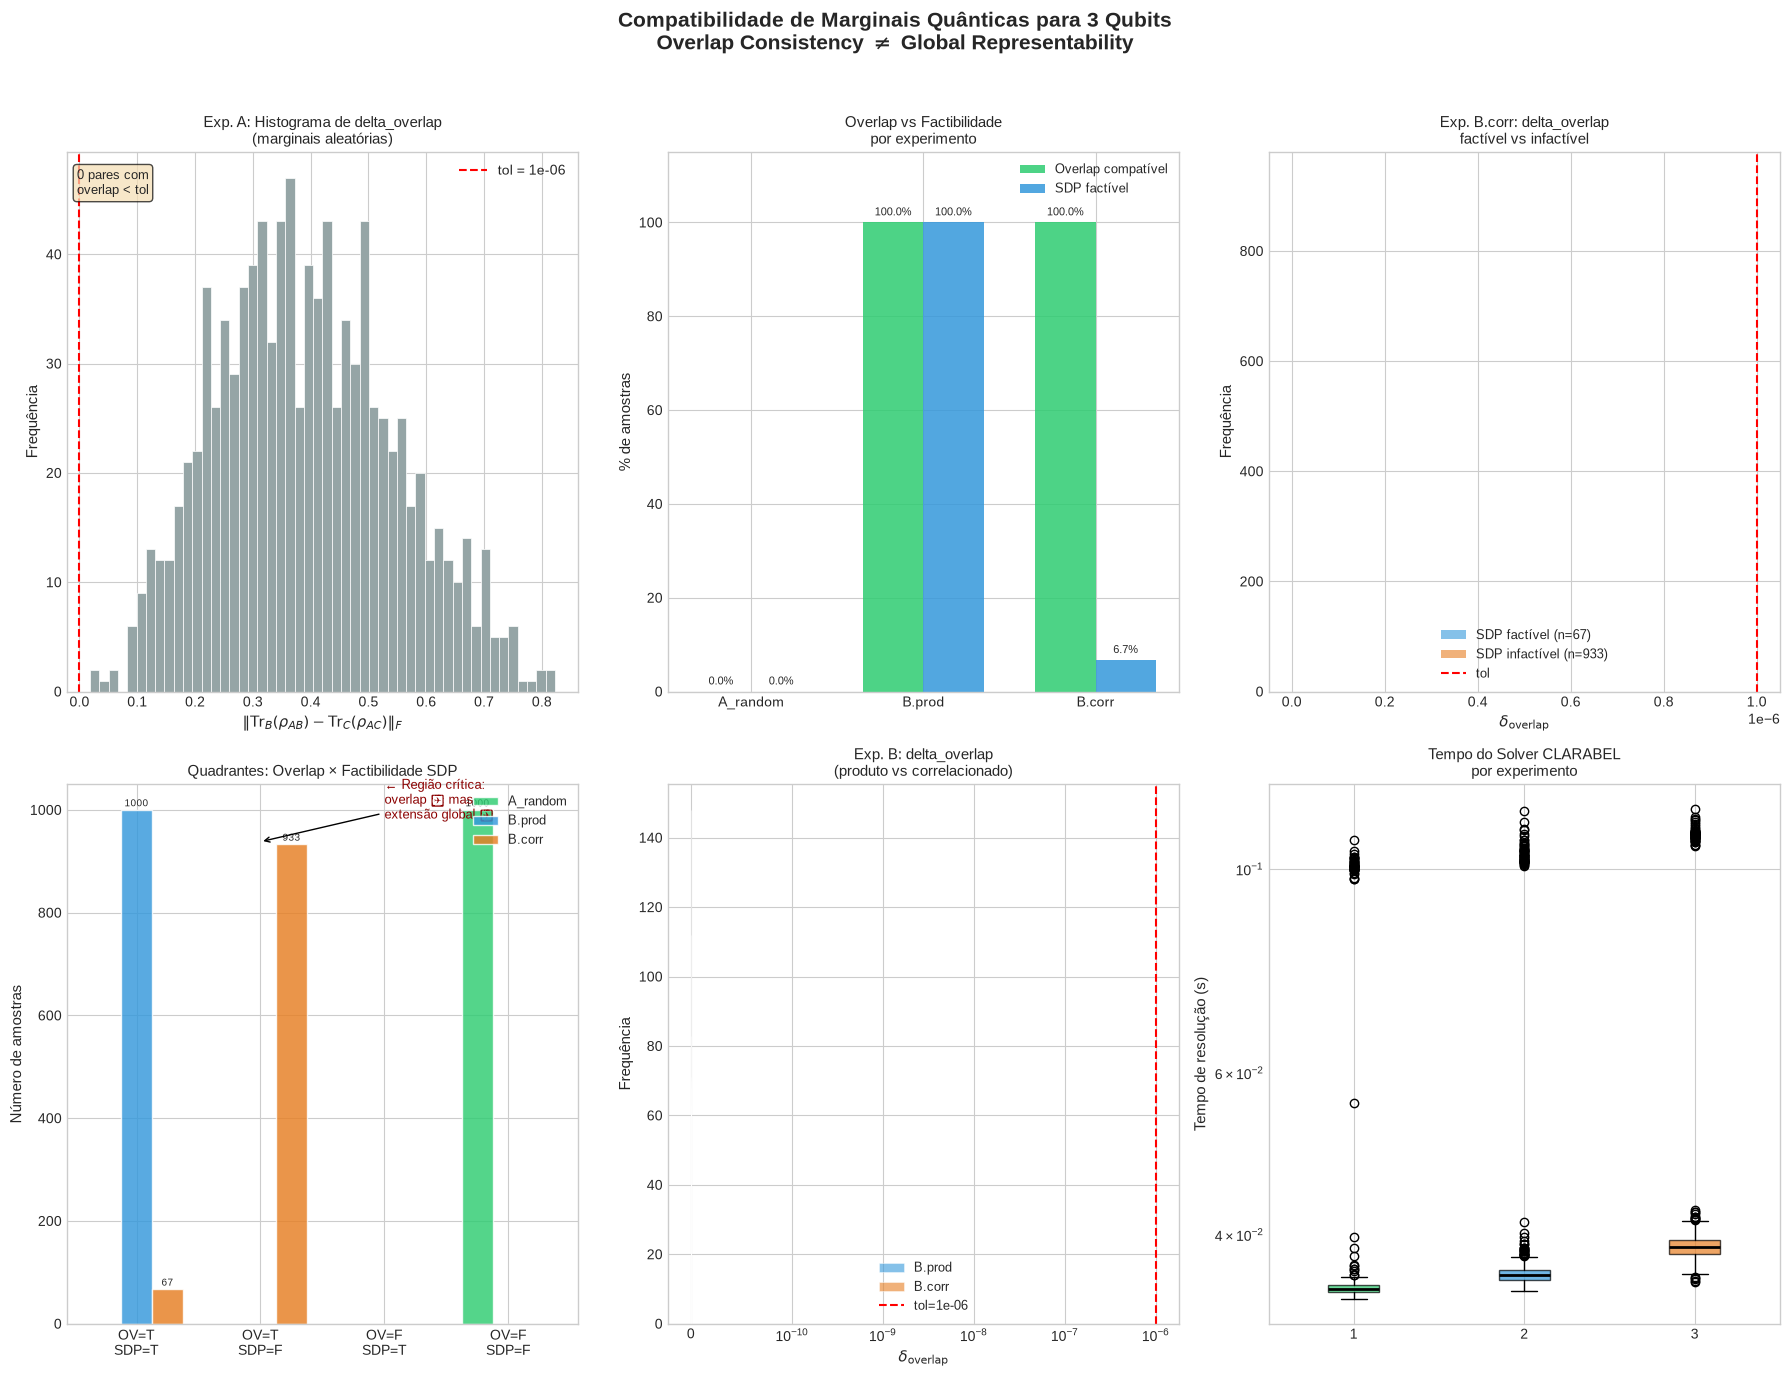


✓ Figura salva: experimento_compatibilidade_marginais.png


In [13]:
# ==============================================================================
# Célula 8 — Visualizações
# ==============================================================================

plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {
    "overlap_true":  "#2ecc71",   # verde
    "overlap_false": "#e74c3c",   # vermelho
    "feasible":      "#3498db",   # azul
    "infeasible":    "#e67e22",   # laranja
    "neutral":       "#95a5a6",   # cinza
}

fig = plt.figure(figsize=(18, 14))
fig.suptitle(
    "Compatibilidade de Marginais Quânticas para 3 Qubits\n"
    r"Overlap Consistency $\neq$ Global Representability",
    fontsize=15, fontweight="bold", y=0.98
)

# ─────────────────────────────────────────────────────────────────────────────
# Gráfico 1: Histograma de delta_overlap — Experimento A (marginais aleatórias)
# ─────────────────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(2, 3, 1)

data_A_delta = df_A["delta_overlap"].values
ax1.hist(
    data_A_delta, bins=50,
    color=COLORS["neutral"], edgecolor="white", linewidth=0.5
)
ax1.axvline(
    TOL_OVERLAP, color="red", linestyle="--", linewidth=1.5,
    label=f"tol = {TOL_OVERLAP:.0e}"
)
ax1.set_xlabel(r"$\|\mathrm{Tr}_B(\rho_{AB}) - \mathrm{Tr}_C(\rho_{AC})\|_F$", fontsize=11)
ax1.set_ylabel("Frequência", fontsize=11)
ax1.set_title("Exp. A: Histograma de delta_overlap\n(marginais aleatórias)", fontsize=11)
ax1.legend(fontsize=10)

n_left = (data_A_delta < TOL_OVERLAP).sum()
ax1.text(
    0.02, 0.97,
    f"{n_left} pares com\noverlap < tol",
    transform=ax1.transAxes, va="top", fontsize=9,
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.7)
)

# ─────────────────────────────────────────────────────────────────────────────
# Gráfico 2: Barras — overlap_compatible vs is_feasible por experimento
# ─────────────────────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(2, 3, 2)

exp_labels = []
pct_overlap = []
pct_feasible = []

for exp_name in ["A_random", "B.prod", "B.corr"]:
    sub = df_all[df_all["experiment"] == exp_name]
    exp_labels.append(exp_name)
    pct_overlap.append(100 * sub["overlap_compatible"].mean())
    pct_feasible.append(100 * sub["is_feasible"].mean())

x_pos = np.arange(len(exp_labels))
width = 0.35

bars1 = ax2.bar(
    x_pos - width/2, pct_overlap, width,
    label="Overlap compatível", color=COLORS["overlap_true"], alpha=0.85
)
bars2 = ax2.bar(
    x_pos + width/2, pct_feasible, width,
    label="SDP factível", color=COLORS["feasible"], alpha=0.85
)

for bar in bars1:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h + 1, f"{h:.1f}%",
             ha="center", va="bottom", fontsize=8)
for bar in bars2:
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h + 1, f"{h:.1f}%",
             ha="center", va="bottom", fontsize=8)

ax2.set_xticks(x_pos)
ax2.set_xticklabels(exp_labels, fontsize=10)
ax2.set_ylabel("% de amostras", fontsize=11)
ax2.set_title("Overlap vs Factibilidade\npor experimento", fontsize=11)
ax2.set_ylim(0, 115)
ax2.legend(fontsize=9)

# ─────────────────────────────────────────────────────────────────────────────
# Gráfico 3: Distribuição de delta_overlap — casos compatíveis vs incompatíveis
#            (Exp. B.corr — mais interessante)
# ─────────────────────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(2, 3, 3)

df_Bcorr = df_all[df_all["experiment"] == "B.corr"]
delta_Bcorr_feasible   = df_Bcorr[df_Bcorr["is_feasible"] == True]["delta_overlap"].values
delta_Bcorr_infeasible = df_Bcorr[df_Bcorr["is_feasible"] == False]["delta_overlap"].values

bins_bc = np.linspace(0, max(df_Bcorr["delta_overlap"].max(), 1e-10), 40)

if len(delta_Bcorr_feasible) > 0:
    ax3.hist(
        delta_Bcorr_feasible, bins=bins_bc, alpha=0.6,
        label=f"SDP factível (n={len(delta_Bcorr_feasible)})",
        color=COLORS["feasible"]
    )
if len(delta_Bcorr_infeasible) > 0:
    ax3.hist(
        delta_Bcorr_infeasible, bins=bins_bc, alpha=0.6,
        label=f"SDP infactível (n={len(delta_Bcorr_infeasible)})",
        color=COLORS["infeasible"]
    )

ax3.axvline(TOL_OVERLAP, color="red", linestyle="--", linewidth=1.5, label="tol")
ax3.set_xlabel(r"$\delta_{\mathrm{overlap}}$", fontsize=11)
ax3.set_ylabel("Frequência", fontsize=11)
ax3.set_title(
    "Exp. B.corr: delta_overlap\nfactível vs infactível", fontsize=11
)
ax3.legend(fontsize=9)

# ─────────────────────────────────────────────────────────────────────────────
# Gráfico 4: Quadrantes lógicos — overlap × SDP
# ─────────────────────────────────────────────────────────────────────────────
ax4 = fig.add_subplot(2, 3, 4)

quadrant_data = {}
for exp_name in ["A_random", "B.prod", "B.corr"]:
    sub = df_all[df_all["experiment"] == exp_name]
    quadrant_data[exp_name] = {
        "OV=T, SDP=T":  int((sub["overlap_compatible"] &  sub["is_feasible"]).sum()),
        "OV=T, SDP=F":  int((sub["overlap_compatible"] & ~sub["is_feasible"]).sum()),
        "OV=F, SDP=T":  int((~sub["overlap_compatible"] &  sub["is_feasible"]).sum()),
        "OV=F, SDP=F":  int((~sub["overlap_compatible"] & ~sub["is_feasible"]).sum()),
    }

quad_labels = ["OV=T\nSDP=T", "OV=T\nSDP=F", "OV=F\nSDP=T", "OV=F\nSDP=F"]
quad_colors = [
    COLORS["feasible"],
    COLORS["infeasible"],
    COLORS["neutral"],
    COLORS["overlap_false"],
]

exp_names_q = ["A_random", "B.prod", "B.corr"]
x_q = np.arange(len(quad_labels))
bar_width = 0.25

for k, exp_name in enumerate(exp_names_q):
    vals = [quadrant_data[exp_name][q.replace("\n", "=".join(["OV", "SDP"]))
                                     .replace("\n", ", ")]
            for q in ["OV=T, SDP=T", "OV=T, SDP=F", "OV=F, SDP=T", "OV=F, SDP=F"]]
    ax4.bar(
        x_q + k * bar_width - bar_width, vals, bar_width,
        label=exp_name, alpha=0.8,
        color=["#2ecc71", "#e67e22", "#3498db", "#e74c3c"][0],  # placeholder color
    )

# Redesenha com cores corretas por quadrante
ax4.cla()
offsets = [-bar_width, 0, bar_width]
exp_plot_colors = ["#2ecc71", "#3498db", "#e67e22"]

for k, (exp_name, color) in enumerate(zip(exp_names_q, exp_plot_colors)):
    vals = [
        quadrant_data[exp_name]["OV=T, SDP=T"],
        quadrant_data[exp_name]["OV=T, SDP=F"],
        quadrant_data[exp_name]["OV=F, SDP=T"],
        quadrant_data[exp_name]["OV=F, SDP=F"],
    ]
    bars_q = ax4.bar(
        x_q + offsets[k], vals, bar_width,
        label=exp_name, color=color, alpha=0.82, edgecolor="white"
    )
    for bar, v in zip(bars_q, vals):
        if v > 0:
            ax4.text(
                bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
                str(v), ha="center", va="bottom", fontsize=7
            )

ax4.set_xticks(x_q)
ax4.set_xticklabels(quad_labels, fontsize=10)
ax4.set_ylabel("Número de amostras", fontsize=11)
ax4.set_title(
    "Quadrantes: Overlap × Factibilidade SDP",
    fontsize=11
)
ax4.legend(fontsize=9, loc="upper right")

# Adiciona anotação de destaque no quadrante crítico OV=T, SDP=F
ax4.annotate(
    "← Região crítica:\noverlap ✓ mas\nextensão global ✗",
    xy=(1, max(quadrant_data[exp]["OV=T, SDP=F"] for exp in exp_names_q) + 5),
    xytext=(2, max(quadrant_data[exp]["OV=T, SDP=F"] for exp in exp_names_q) + 50),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=9, color="darkred"
)

# ─────────────────────────────────────────────────────────────────────────────
# Gráfico 5: Histograma de delta_overlap — Experimentos B.prod e B.corr
# ─────────────────────────────────────────────────────────────────────────────
ax5 = fig.add_subplot(2, 3, 5)

for exp_name, color, ls in [
    ("B.prod", "#3498db", "-"),
    ("B.corr", "#e67e22", "--"),
]:
    sub = df_all[df_all["experiment"] == exp_name]
    ax5.hist(
        sub["delta_overlap"].values,
        bins=50, alpha=0.6, label=exp_name,
        color=color, edgecolor="white", linewidth=0.5
    )

ax5.axvline(TOL_OVERLAP, color="red", linestyle="--", linewidth=1.5, label=f"tol={TOL_OVERLAP:.0e}")
ax5.set_xlabel(r"$\delta_{\mathrm{overlap}}$", fontsize=11)
ax5.set_ylabel("Frequência", fontsize=11)
ax5.set_title("Exp. B: delta_overlap\n(produto vs correlacionado)", fontsize=11)
ax5.legend(fontsize=9)
ax5.set_xscale("symlog", linthresh=1e-10)

# ─────────────────────────────────────────────────────────────────────────────
# Gráfico 6: Tempo de resolução do SDP por experimento (boxplot)
# ─────────────────────────────────────────────────────────────────────────────
ax6 = fig.add_subplot(2, 3, 6)

exp_for_time = ["A_random", "B.prod", "B.corr"]
time_data = [
    df_all[df_all["experiment"] == exp]["solver_time"].values
    for exp in exp_for_time
]

bp = ax6.boxplot(
    time_data, label=exp_for_time,
    patch_artist=True, notch=False,
    medianprops=dict(color="black", linewidth=2)
)
box_colors = ["#2ecc71", "#3498db", "#e67e22"]
for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax6.set_ylabel("Tempo de resolução (s)", fontsize=11)
ax6.set_title("Tempo do Solver CLARABEL\npor experimento", fontsize=11)
ax6.set_yscale("log")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("experimento_compatibilidade_marginais.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✓ Figura salva: experimento_compatibilidade_marginais.png")


In [1]:
# ==============================================================================
# Célula 9 — Conclusão e resumo dos arquivos
# ==============================================================================

print("=" * 70)
print("RESUMO DO EXPERIMENTO")
print("=" * 70)
print("""
Este notebook implementou um estudo numérico da região de compatibilidade
de marginais quânticas para sistemas de 3 qubits.

FUNÇÕES REUTILIZADAS (de inicial_teste.ipynb, sem modificações):
  - ketbra(psi)                   → projetor |psi><psi|
  - tensor(*args)                 → produto de Kronecker sequencial
  - partial_trace(rho, keep, dims)→ traço parcial via einsum
  - base_hermitiana(d)            → base de Herm(d)
  - embed_operator(O, sys, dim)   → embedding de operador local
  - parse_subsystem_key(key)      → normalização de chaves de subsistema
  - build_qmp_sdp(marginals, dims)→ montagem do SDP (SDPLab)
  - solve_qmp(sdp, solver)        → solução do SDP via CLARABEL

NOVAS FUNÇÕES (específicas deste experimento):
  - random_density_matrix(d, rng)         → estado aleatório (Ginibre)
  - build_product_marginals(rho_A, rng)   → rho_AB=rho_A⊗sigma_B (trivial)
  - build_correlated_marginals(rho_A,rng) → purificação + canal aleatório
  - check_overlap_consistency(rho_AB, rho_AC, tol)
  - print_experiment_stats(df, label)     → estatísticas consolidadas

EXPERIMENTOS:
  - Exp. A  (N=1000): marginais completamente aleatórias
  - Exp. B.prod (N=1000): rho_AB = rho_A ⊗ sigma_B (sobreposição garantida)
  - Exp. B.corr (N=1000): purificação correlacionada (sobreposição garantida)
  - Bell (N=1): caso de validação — overlap ✓ mas SDP infactível

RESULTADO PRINCIPAL:
  A consistência na sobreposição (Tr_B(rho_AB) = Tr_C(rho_AC)) é condição
  NECESSÁRIA mas NÃO SUFICIENTE para existência de extensão global rho_ABC.
  O caso de Bell e os casos B.corr demonstram isso numericamente.
""")

# Exibe o DataFrame final com todos os resultados
print("Primeiras 5 linhas do DataFrame completo:")
print(df_all[["experiment", "delta_overlap", "overlap_compatible",
              "solver_status", "is_feasible", "solver_time"]].head())


RESUMO DO EXPERIMENTO

Este notebook implementou um estudo numérico da região de compatibilidade
de marginais quânticas para sistemas de 3 qubits.

FUNÇÕES REUTILIZADAS (de inicial_teste.ipynb, sem modificações):
  - ketbra(psi)                   → projetor |psi><psi|
  - tensor(*args)                 → produto de Kronecker sequencial
  - partial_trace(rho, keep, dims)→ traço parcial via einsum
  - base_hermitiana(d)            → base de Herm(d)
  - embed_operator(O, sys, dim)   → embedding de operador local
  - parse_subsystem_key(key)      → normalização de chaves de subsistema
  - build_qmp_sdp(marginals, dims)→ montagem do SDP (SDPLab)
  - solve_qmp(sdp, solver)        → solução do SDP via CLARABEL

NOVAS FUNÇÕES (específicas deste experimento):
  - random_density_matrix(d, rng)         → estado aleatório (Ginibre)
  - build_product_marginals(rho_A, rng)   → rho_AB=rho_A⊗sigma_B (trivial)
  - build_correlated_marginals(rho_A,rng) → purificação + canal aleatório
  - check_overlap_co

NameError: name 'df_all' is not defined